<a href="https://colab.research.google.com/github/gapalfaro-cmyk/Proyecto-de-fin-de-modulo-5---Alfaro-Badillo-Cruz-Perez-Rupit/blob/main/Entregable_Tarea_5_3_Alfaro_Cruz_Perez_Rupit_Medea.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Contaminación Atmosférica y Calidad del Aire (PM2.5)

## Exploración y Preprocesamiento
Rúbrica: 15% Manejo adecuado de valores nulos, codificación de categóricas y escalamiento de variables (crítico para GLM, $L_1$ / $L_2$ y Redes Neuronales).

## Resumen de la programación realizada en este código

1) Se sacaron los estadísticos
2) Creamos tres ejercicios de df imputados, el primero con medianas, el segundo con medias y el tercero con mice.  
3) Encontramos que: La información solo tenía datos con NA en la columna por modelar y representan menos del ¿4.7%? del total de datos, por lo que ...

In [ ]:
# Incluir librerías necesarias para procesamiento y graficación
import pandas as pd # Manejo de datos en tablas
import numpy as np # Operaciones numéricas
import matplotlib.pyplot as plt  # Gráficas
import seaborn as sns  # Gráficas más avanzadas
from sklearn.experimental import enable_iterative_imputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.compose import ColumnTransformer

In [ ]:
# Importar la información
df = pd.read_csv("PRSA_data_2010.1.1-2014.12.31.csv")

In [ ]:
# Mostrar las primeras 5 filas
df.sample(10)

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
20695,20696,2012,5,12,7,128.0,14,15.0,1011.0,cv,0.89,0,9
31551,31552,2013,8,7,15,26.0,20,27.0,1003.0,NW,19.22,0,1
12392,12393,2011,6,1,8,16.0,9,25.0,1008.0,NW,196.70,0,0
16055,16056,2011,10,31,23,264.0,12,13.0,1023.0,cv,4.02,0,0
7700,7701,2010,11,17,20,525.0,-2,1.0,1022.0,NW,1.78,0,0
32006,32007,2013,8,26,14,30.0,11,33.0,1005.0,SE,8.94,0,0
8152,8153,2010,12,6,16,13.0,-21,4.0,1029.0,NW,255.65,0,0
20167,20168,2012,4,20,7,185.0,13,15.0,1016.0,SE,0.89,0,0
35832,35833,2014,2,2,0,141.0,-1,2.0,1012.0,SE,29.96,0,0
959,960,2010,2,9,23,27.0,-18,1.0,1027.0,NE,12.07,0,0


# Glosario de Columnas Relevantes

pm2.5 --> PM25: Concentración de partículas PM2.5 (material particulado fino)

DEWP: Punto de rocío (Dew Point)

TEMP: Temperatura ambiente

PRES: Presión atmosférica

cbwd --> WIND_DIRECTION : Dirección combinada del viento

lws --> WIND_SPEED: velocidad acumulada del viento

ls: Horas acumuladas de nieve

lr: Horas acumuladas de lluvia

 -NW: Viento del noroeste

 -NE: Viento del noreste

 -SE: Viento del sureste

 -cv: Calm Variable (viento muy debil o dirección variable). *Combinación de las tres anteriores, sin rumbo fijo.

In [ ]:
# Revisar el tipos de datos y columnas presentes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      43824 non-null  int64  
 1   year    43824 non-null  int64  
 2   month   43824 non-null  int64  
 3   day     43824 non-null  int64  
 4   hour    43824 non-null  int64  
 5   pm2.5   41757 non-null  float64
 6   DEWP    43824 non-null  int64  
 7   TEMP    43824 non-null  float64
 8   PRES    43824 non-null  float64
 9   cbwd    43824 non-null  object 
 10  Iws     43824 non-null  float64
 11  Is      43824 non-null  int64  
 12  Ir      43824 non-null  int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 4.3+ MB


In [ ]:
#Renombrar encabezados
df = df.rename(columns={"No": "NO",
                        "year": "YEAR",
                        "month": "MONTH",
                        "day": "DAY",
                        "hour": "HOUR",
                        "pm2.5": "PM25",
                        "DEWP": "DEWPOINT",
                        "TEMP": "TEMP",
                        "PRES": "PRESION",
                        "cbwd": "WIND_DIRECTION",
                        "Iws": "WIND_SPEED",
                        "Is": "SNOW",
                        "Ir": "RAIN"})
df.info()  # Revisar el tipos de datos y columnas presentes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   NO              43824 non-null  int64  
 1   YEAR            43824 non-null  int64  
 2   MONTH           43824 non-null  int64  
 3   DAY             43824 non-null  int64  
 4   HOUR            43824 non-null  int64  
 5   PM25            41757 non-null  float64
 6   DEWPOINT        43824 non-null  int64  
 7   TEMP            43824 non-null  float64
 8   PRESION         43824 non-null  float64
 9   WIND_DIRECTION  43824 non-null  object 
 10  WIND_SPEED      43824 non-null  float64
 11  SNOW            43824 non-null  int64  
 12  RAIN            43824 non-null  int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 4.3+ MB


In [ ]:
# Crear una columna con la fecha a partir de year, month, day y hour
# Mostrar resultados
df['FECHA'] = pd.to_datetime(df[['YEAR', 'MONTH', 'DAY', 'HOUR']]) # Crea una columna con la fecha con hora
print("Rango de fechas del dataset:")
print(f"Desde: {df['FECHA'].min()} hasta {df['FECHA'].max()}")

# Observamos que las mediciones con cada hora
display(df["HOUR"].value_counts())

# Crear otra sin columna HOUR
df['FECHA_SIN_H'] = pd.to_datetime(df[['YEAR', 'MONTH', 'DAY']]) # Crea una columna con la fecha
print("Rango de fechas del dataset:")
print(f"Desde: {df['FECHA_SIN_H'].min()} hasta {df['FECHA_SIN_H'].max()}")

# Frecuencia de observaciones por día
display(df["FECHA"].value_counts())
display(df["FECHA_SIN_H"].value_counts())


Rango de fechas del dataset:
Desde: 2010-01-01 00:00:00 hasta 2014-12-31 23:00:00


,count
HOUR,
0,1826
1,1826
2,1826
3,1826
4,1826
5,1826
6,1826
7,1826
8,1826


Rango de fechas del dataset:
Desde: 2010-01-01 00:00:00 hasta 2014-12-31 00:00:00


,count
FECHA,
2014-12-31 07:00:00,1
2014-12-31 06:00:00,1
2014-12-31 05:00:00,1
2014-12-31 04:00:00,1
2014-12-31 03:00:00,1
...,...
2010-01-01 04:00:00,1
2010-01-01 03:00:00,1
2010-01-01 02:00:00,1


,count
FECHA_SIN_H,
2014-12-31,24
2010-01-01,24
2014-12-15,24
2014-12-14,24
2014-12-13,24
...,...
2010-01-07,24
2010-01-06,24
2010-01-05,24


In [ ]:
# Análisis de métricas principales de la información
df.drop(columns=["NO", "YEAR", "MONTH", "DAY", "HOUR"]).describe() # Estadísticas básicas sin considerar las fechas

,PM25,DEWPOINT,TEMP,PRESION,WIND_SPEED,SNOW,RAIN,FECHA,FECHA_SIN_H
count,41757.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824,43824
mean,98.613215,1.817246,12.448521,1016.447654,23.889140,0.052734,0.194916,2012-07-01 23:30:00,2012-07-01 12:00:00
min,0.000000,-40.000000,-19.000000,991.000000,0.450000,0.000000,0.000000,2010-01-01 00:00:00,2010-01-01 00:00:00
25%,29.000000,-10.000000,2.000000,1008.000000,1.790000,0.000000,0.000000,2011-04-02 11:45:00,2011-04-02 00:00:00
50%,72.000000,2.000000,14.000000,1016.000000,5.370000,0.000000,0.000000,2012-07-01 23:30:00,2012-07-01 12:00:00
75%,137.000000,15.000000,23.000000,1025.000000,21.910000,0.000000,0.000000,2013-10-01 11:15:00,2013-10-01 00:00:00
max,994.000000,28.000000,42.000000,1046.000000,585.600000,27.000000,36.000000,2014-12-31 23:00:00,2014-12-31 00:00:00
std,92.050387,14.433440,12.198613,10.268698,50.010635,0.760375,1.415867,NaN,NaN


Nota: El rango de las variables (diferente entre ellas) puede afectar el modelo por lo que es posible que se deba normalizar

In [ ]:
threshold = df['PM25'].quantile(0.99)
filtered_df = df[df['PM25'] >= threshold]
filtered_df['PM25'].describe()

,PM25
count,423.000000
mean,493.101655
std,87.652354
min,420.000000
25%,439.000000
50%,470.000000
75%,508.000000
max,994.000000


En este bloque revisamos los outliers variando el percentil, no eliminamos dato.

In [ ]:
# Revisión de datos nulos de la información
df.isnull().sum()

,0
NO,0
YEAR,0
MONTH,0
DAY,0
HOUR,0
PM25,2067
DEWPOINT,0
TEMP,0
PRESION,0
WIND_DIRECTION,0


In [ ]:
# Porcentaje de vacíos en la información por modelar
x = 2067/43824*100
print(round(x, 3), '%')

4.717 %


Sólo la variable por modelar tiene valores nulos y es menos del 4.72%

Text(0.5, 0, 'Concentración μg/m³')

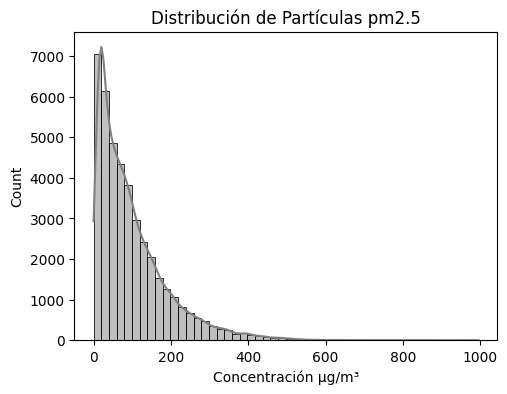

In [ ]:
# Configuración de los gráficos
plt.figure(figsize=(12, 4))

# 1. Gráfico para ver la distribución de pm2.5 e identificar sesgos o valores atípicos (outliers)
plt.subplot(1, 2, 1)
sns.histplot(df['PM25'].dropna(), bins=50, kde=True, color='grey')
plt.title('Distribución de Partículas pm2.5')
plt.xlabel('Concentración μg/m³')

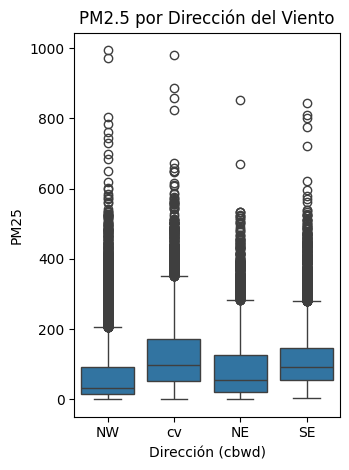

In [ ]:
# 2. Gráfico de caja para ver cómo afecta el viento en calma ('cv') frente a los otros a las PM2.5
plt.subplot(1, 2, 2)
sns.boxplot(x='WIND_DIRECTION', y='PM25', data=df)
plt.title('PM2.5 por Dirección del Viento')
plt.xlabel('Dirección (cbwd)')
plt.tight_layout()
plt.show()

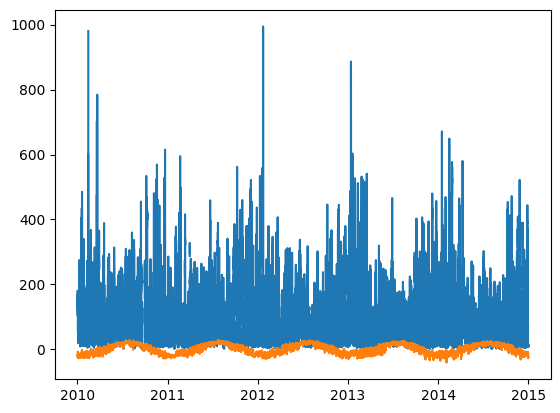

In [ ]:
plt.plot(df["FECHA"], df["PM25"], label="pm2.5")
plt.plot(df["FECHA"], df["DEWPOINT"], label="DEWP")

In [ ]:
# Rellenar nulos con la mediana
# df['pm2.5'] = df['pm2.5'].fillna(df['pm2.5'].median())

Opción 1: Eliminar nulos

Opción 2: Rellenar con la media

Opción 3: Rellenar con interpolación temporal

In [ ]:
# Limpio de NA
df_clean = df.dropna(subset=['PM25'])
print(len(df_clean))

41757


Agrego lo demas..

In [ ]:
print("Numero de filas del dataset: ", len(df))
print("")
df.describe()
df.info()
df.sample(10)
print("")
print(df[["SNOW", "RAIN"]].value_counts())

Numero de filas del dataset:  43824

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   NO              43824 non-null  int64         
 1   YEAR            43824 non-null  int64         
 2   MONTH           43824 non-null  int64         
 3   DAY             43824 non-null  int64         
 4   HOUR            43824 non-null  int64         
 5   PM25            41757 non-null  float64       
 6   DEWPOINT        43824 non-null  int64         
 7   TEMP            43824 non-null  float64       
 8   PRESION         43824 non-null  float64       
 9   WIND_DIRECTION  43824 non-null  object        
 10  WIND_SPEED      43824 non-null  float64       
 11  SNOW            43824 non-null  int64         
 12  RAIN            43824 non-null  int64         
 13  FECHA           43824 non-null  datetime64[ns]
 14  FECHA_SIN_H     4

In [ ]:
print(df.isna().sum())
print(" ")
print("Los valores de la unica columna tipo string (WIND_DIRECTION) son:")
print(df["WIND_DIRECTION"].value_counts())
print("Estos valores se les aplica One-hot encoding al ser muy pocas las categorias")

NO                   0
YEAR                 0
MONTH                0
DAY                  0
HOUR                 0
PM25              2067
DEWPOINT             0
TEMP                 0
PRESION              0
WIND_DIRECTION       0
WIND_SPEED           0
SNOW                 0
RAIN                 0
FECHA                0
FECHA_SIN_H          0
dtype: int64
 
Los valores de la unica columna tipo string (WIND_DIRECTION) son:
WIND_DIRECTION
SE    15290
NW    14150
cv     9387
NE     4997
Name: count, dtype: int64
Estos valores se les aplica One-hot encoding al ser muy pocas las categorias


In [ ]:
# Dropping Data. Nueva dataset que elimina las files con NAs solo de la columna de pm2.5.

df_clean = df.dropna(subset="PM25")
df_clean.isna().sum()
len(df_clean)

# Impute data. Nuevo dataset imputado... Primero para decidir que tipo de Imputación realizar
# necesito saber que tan independientes o dependientes son mis variables entre si.
# Para ello necesito visualizar posibles correlaciones o relaciones estadisticas entre ellas.

# Dadas las graficas de abajo quiero diferenciar que variables son dependientes de otras, y ver como esto afecta al tipo de imputacion
# despues, normalizamos

41757

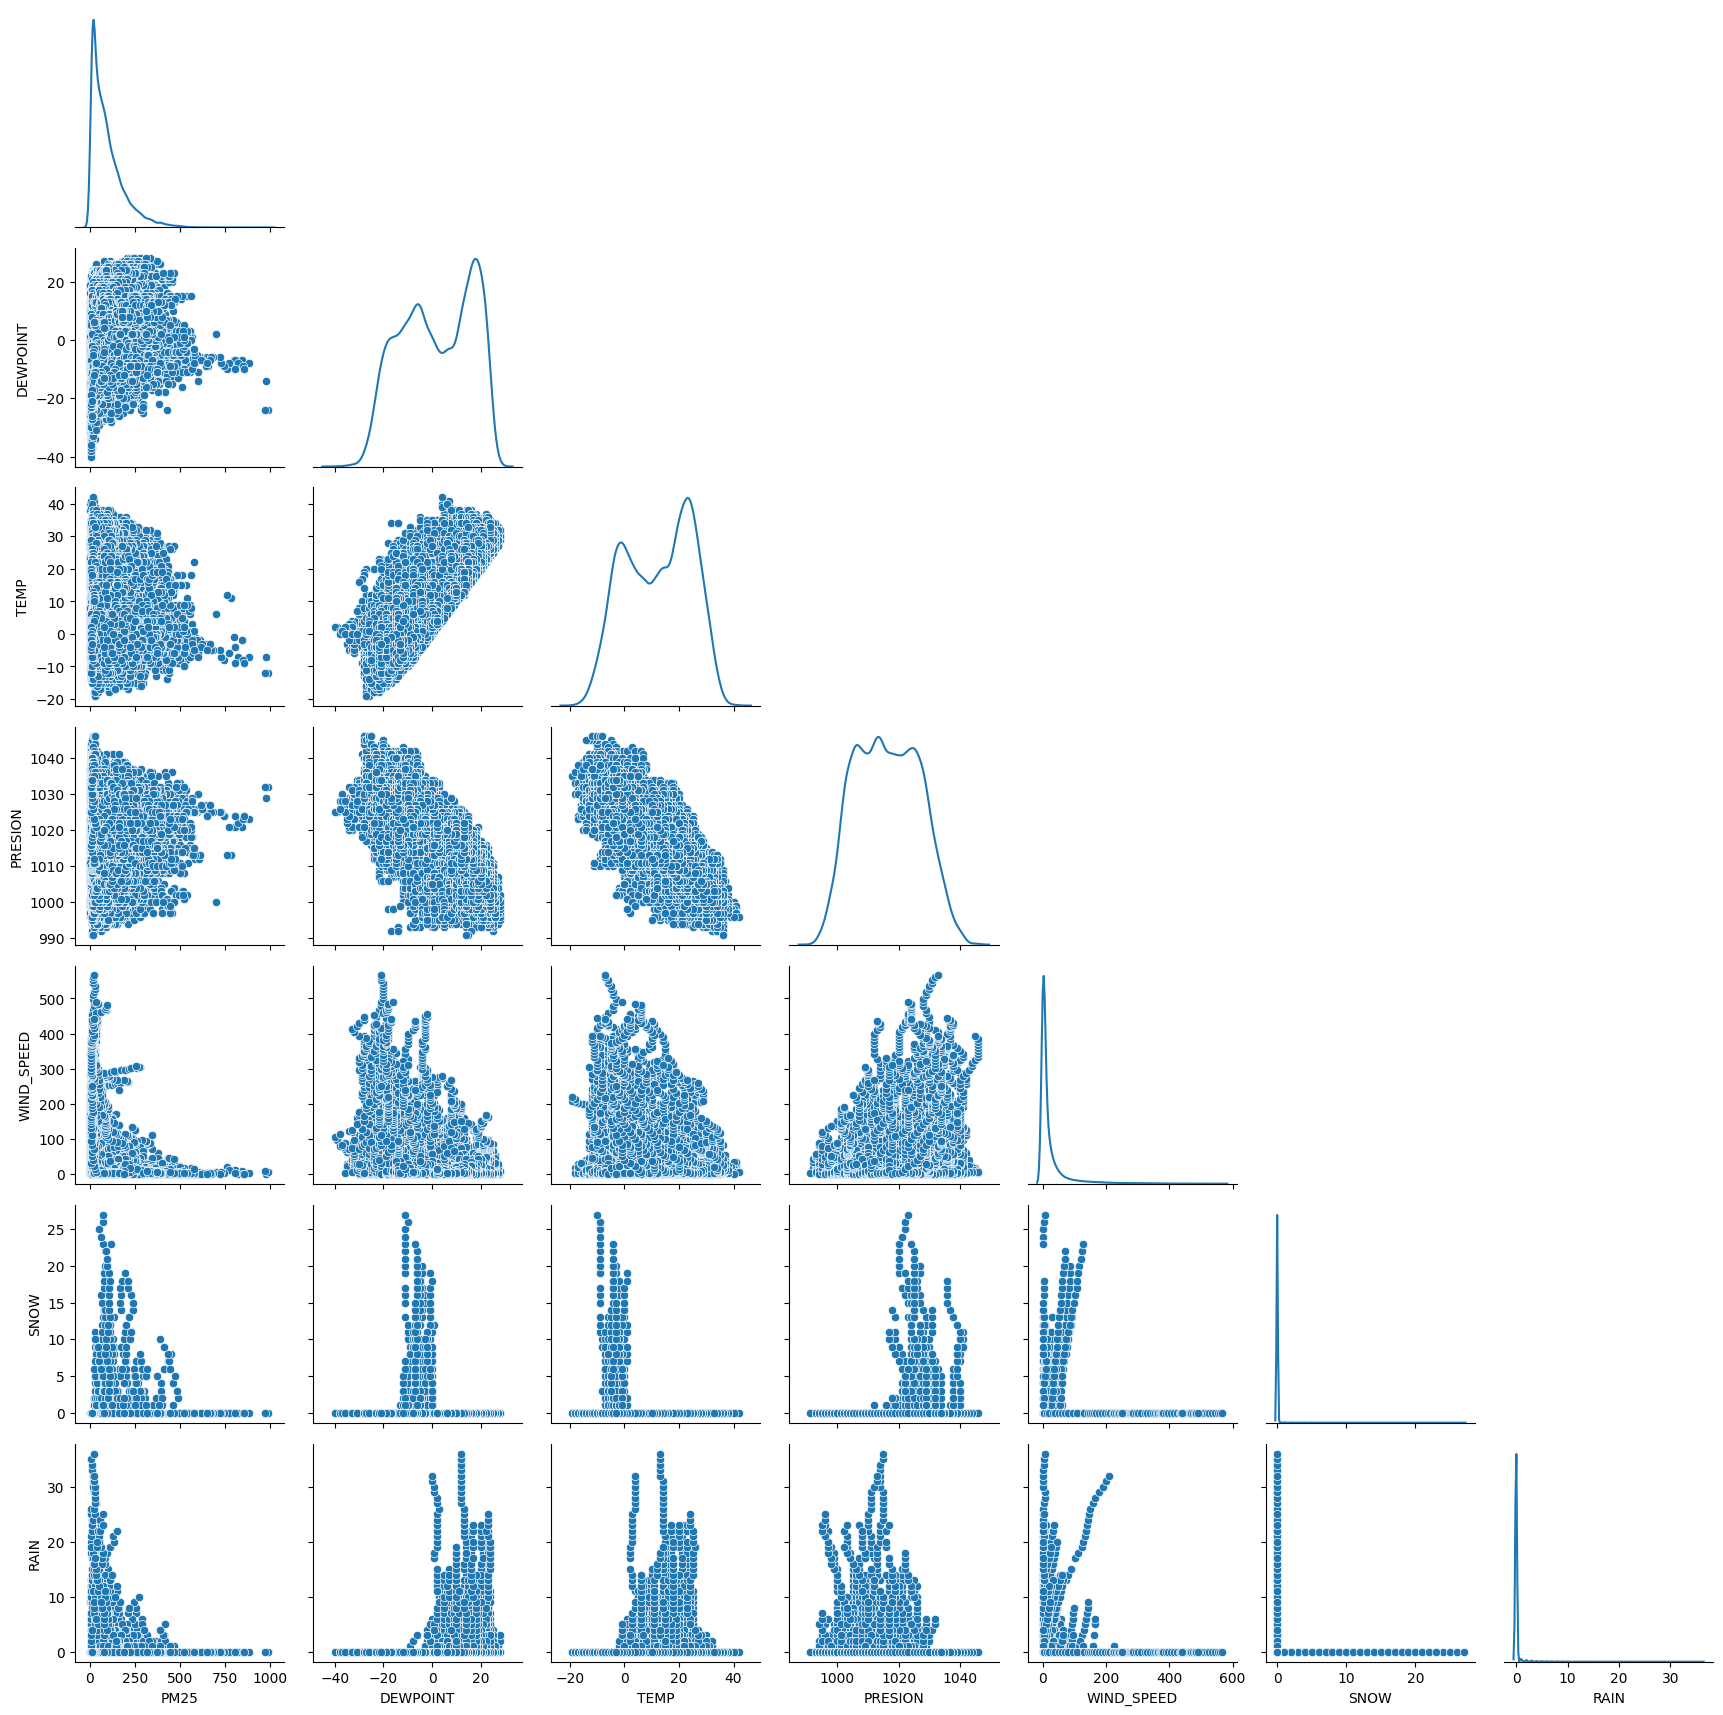

In [ ]:
g = sns.PairGrid(df_clean[["PM25", "DEWPOINT", "TEMP", "PRESION", "WIND_SPEED", "SNOW", "RAIN"]],
                 diag_sharey=False,
                 corner=True
                )
g.map_diag(sns.kdeplot)
g.map_lower(sns.scatterplot)
# llevar a la otra fase

In [ ]:
df["FECHA"].sample(3)


,FECHA
13782,2011-07-29 06:00:00
42081,2014-10-20 09:00:00
26726,2013-01-18 14:00:00


<function matplotlib.pyplot.show(close=None, block=None)>

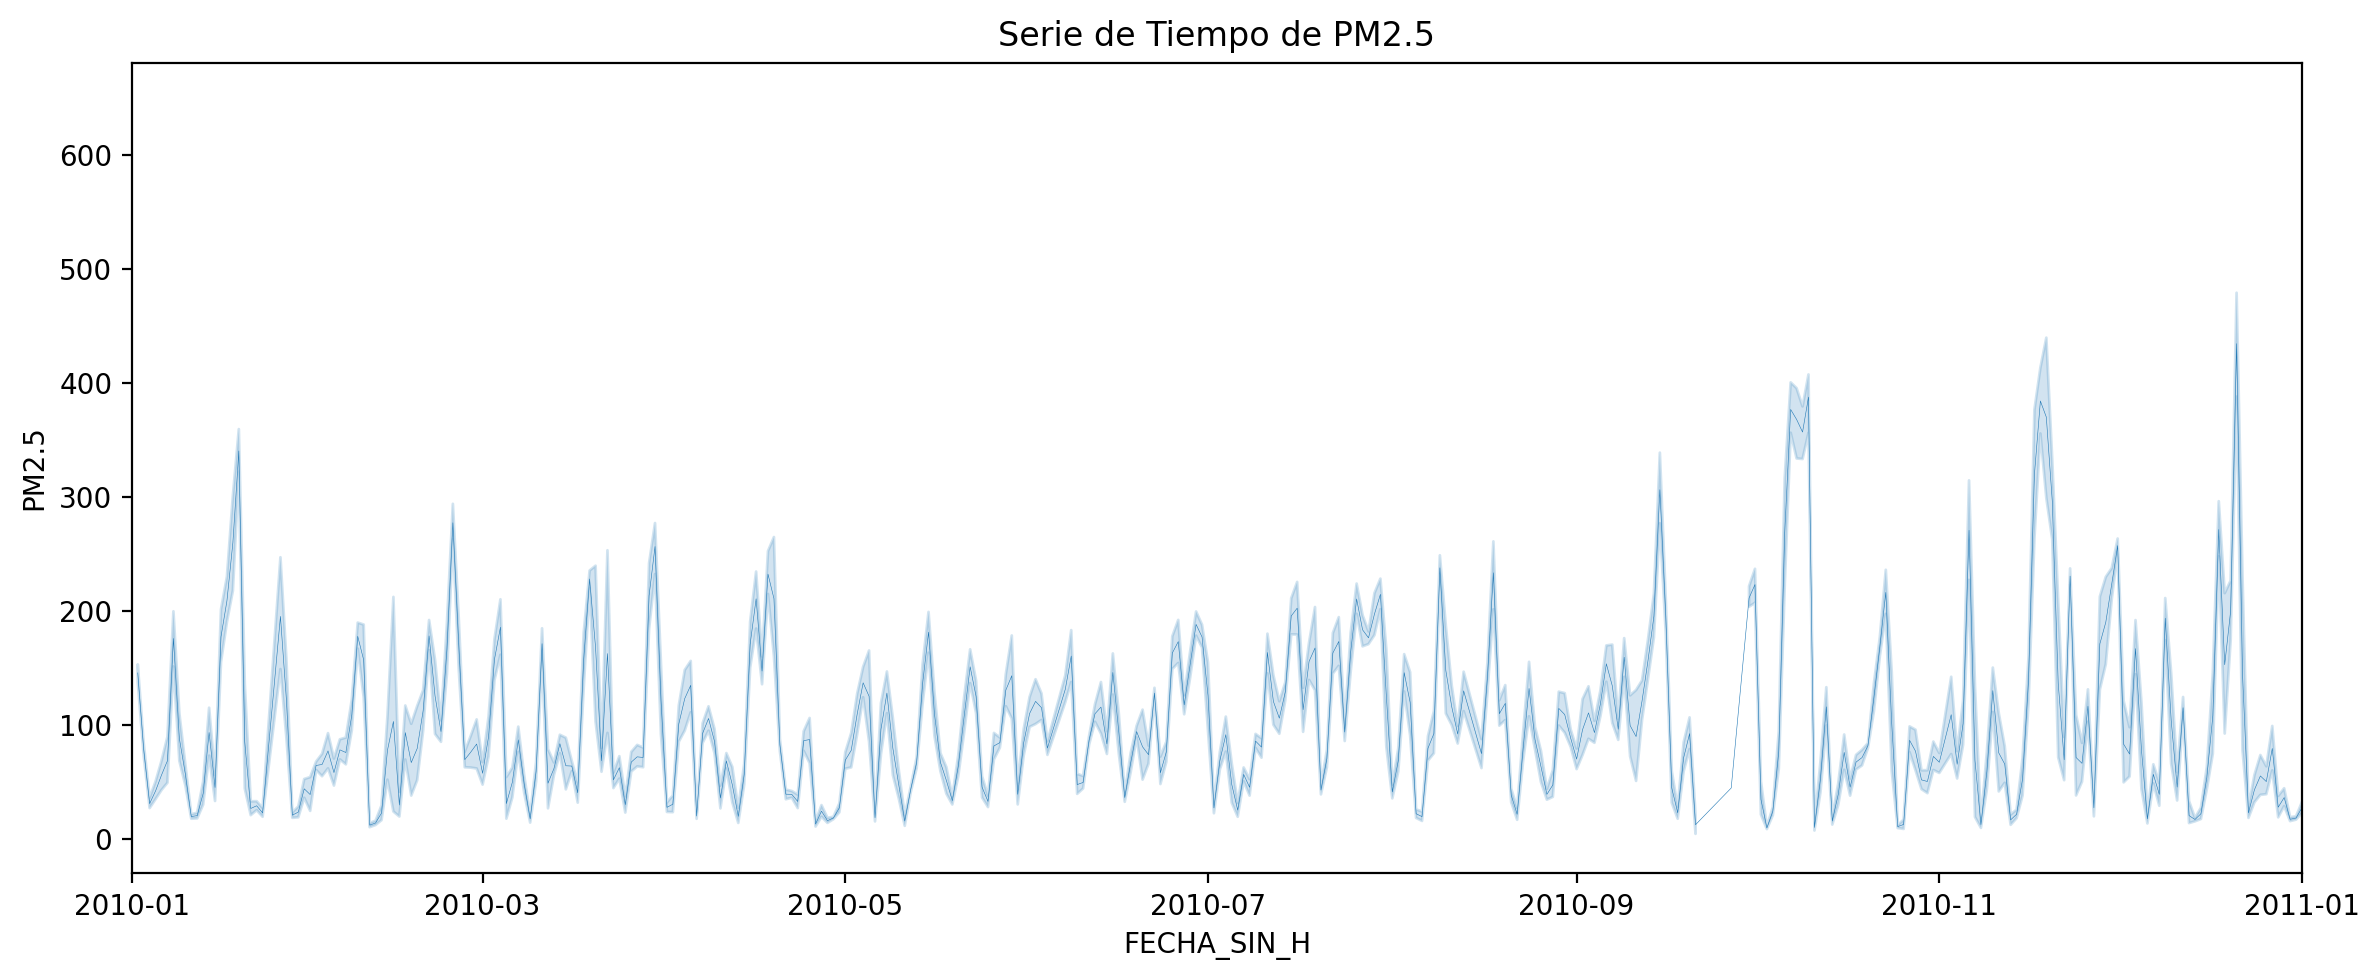

In [ ]:
# Time Series only for pm2.5 values

# Ojo!!! puede que nos este apilando los datos ya que tenemos mas de un dato por dia (dado la variable horas)

plt.rcParams["figure.dpi"] = 200
fig, ax = plt.subplots(figsize=(12,5))
sns.lineplot(x="FECHA_SIN_H", y="PM25",
             data=df,
             linewidth=0.2,
            )
ax.set(
    ylabel="PM2.5",
    title="Serie de Tiempo de PM2.5",
)
ax.tick_params(axis="both", labelsize=10)

plt.xlim(pd.Timestamp("2010-01-01"), pd.Timestamp("2011-01-01"))
plt.tight_layout()
plt.show

# Time Series por año
# Pendiente ver si sale...

<function matplotlib.pyplot.show(close=None, block=None)>

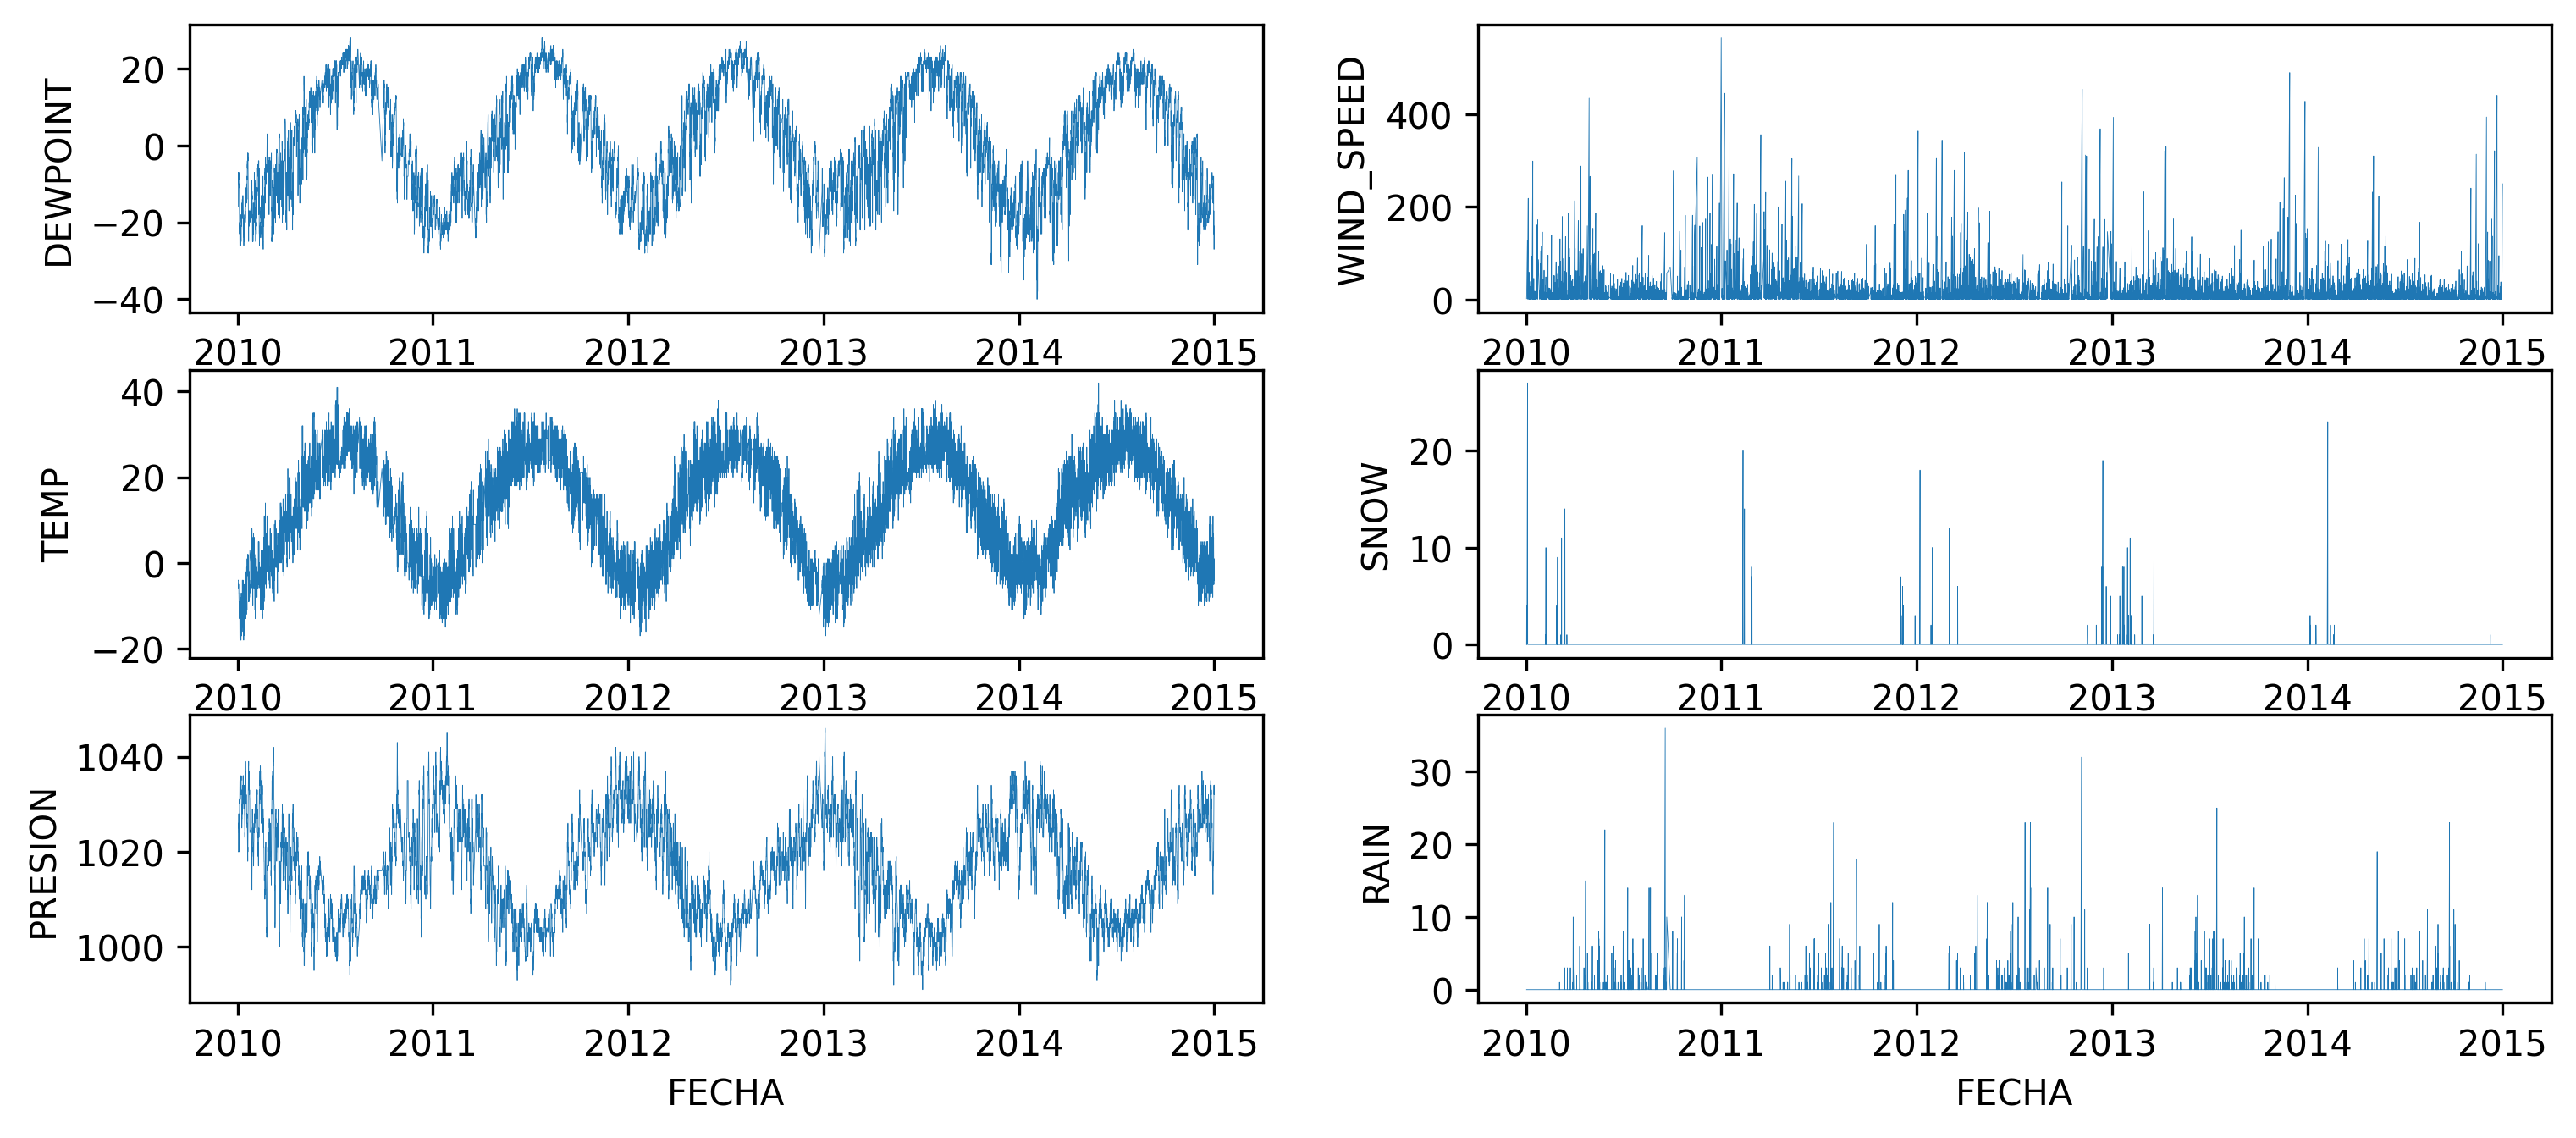

In [ ]:
# La recomendación de las series de tiempo (en un mismo figure)

plt.rcParams["figure.dpi"] = 300

fig, axs = plt.subplots(3,2, figsize=(12,5))
sns.lineplot(x="FECHA", y="DEWPOINT", data=df_clean, linewidth=0.2, ax=axs[0,0])
sns.lineplot(x="FECHA", y="TEMP", data=df_clean, linewidth=0.2, ax=axs[1,0])
sns.lineplot(x="FECHA", y="PRESION", data=df_clean, linewidth=0.2, ax=axs[2,0])
sns.lineplot(x="FECHA", y="WIND_SPEED", data=df_clean, linewidth=0.2, ax=axs[0,1])
sns.lineplot(x="FECHA", y="SNOW", data=df_clean, linewidth=0.2, ax=axs[1,1])
sns.lineplot(x="FECHA", y="RAIN", data=df_clean, linewidth=0.2, ax=axs[2,1])

plt.show

Preparando los dataset para ML:
- Codificación (One-hot encoding) para la columna `WIND_DIRECTION` (única columna tipo string).
- Creación de datasets con diferentes tipos de IMPUTACION para las columnas `PM25`.
- Normalizar datasets

In [ ]:
# One-hot encoding para WIND_DIRECTION.
encoder = OneHotEncoder(sparse_output=False)
encoded_data = encoder.fit_transform(df[["WIND_DIRECTION"]])
encoded_columns = encoder.get_feature_names_out(["WIND_DIRECTION"])
encoded_df = pd.DataFrame(encoded_data, columns=encoded_columns)
df_final = pd.concat([df.drop('WIND_DIRECTION', axis=1), encoded_df], axis=1)
display(df_final.head(3))

# df_final es nuestro dataframe ya codificado!

# solo como comentario:
# Descubri que pandas tmb lo hace de una forma mas sencilla...
# df_encoded_by_pandas = pd.get_dummies(df, columns=["WIND_DIRECTION"], dtype=int)
# print("\n--- pandas way (.get_dummies) ---")
# display(df_encoded_by_pandas.head(3))

,NO,YEAR,MONTH,DAY,HOUR,PM25,DEWPOINT,TEMP,PRESION,WIND_SPEED,SNOW,RAIN,FECHA,FECHA_SIN_H,WIND_DIRECTION_NE,WIND_DIRECTION_NW,WIND_DIRECTION_SE,WIND_DIRECTION_cv
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,1.79,0,0,2010-01-01 00:00:00,2010-01-01,0.0,1.0,0.0,0.0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,4.92,0,0,2010-01-01 01:00:00,2010-01-01,0.0,1.0,0.0,0.0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,6.71,0,0,2010-01-01 02:00:00,2010-01-01,0.0,1.0,0.0,0.0


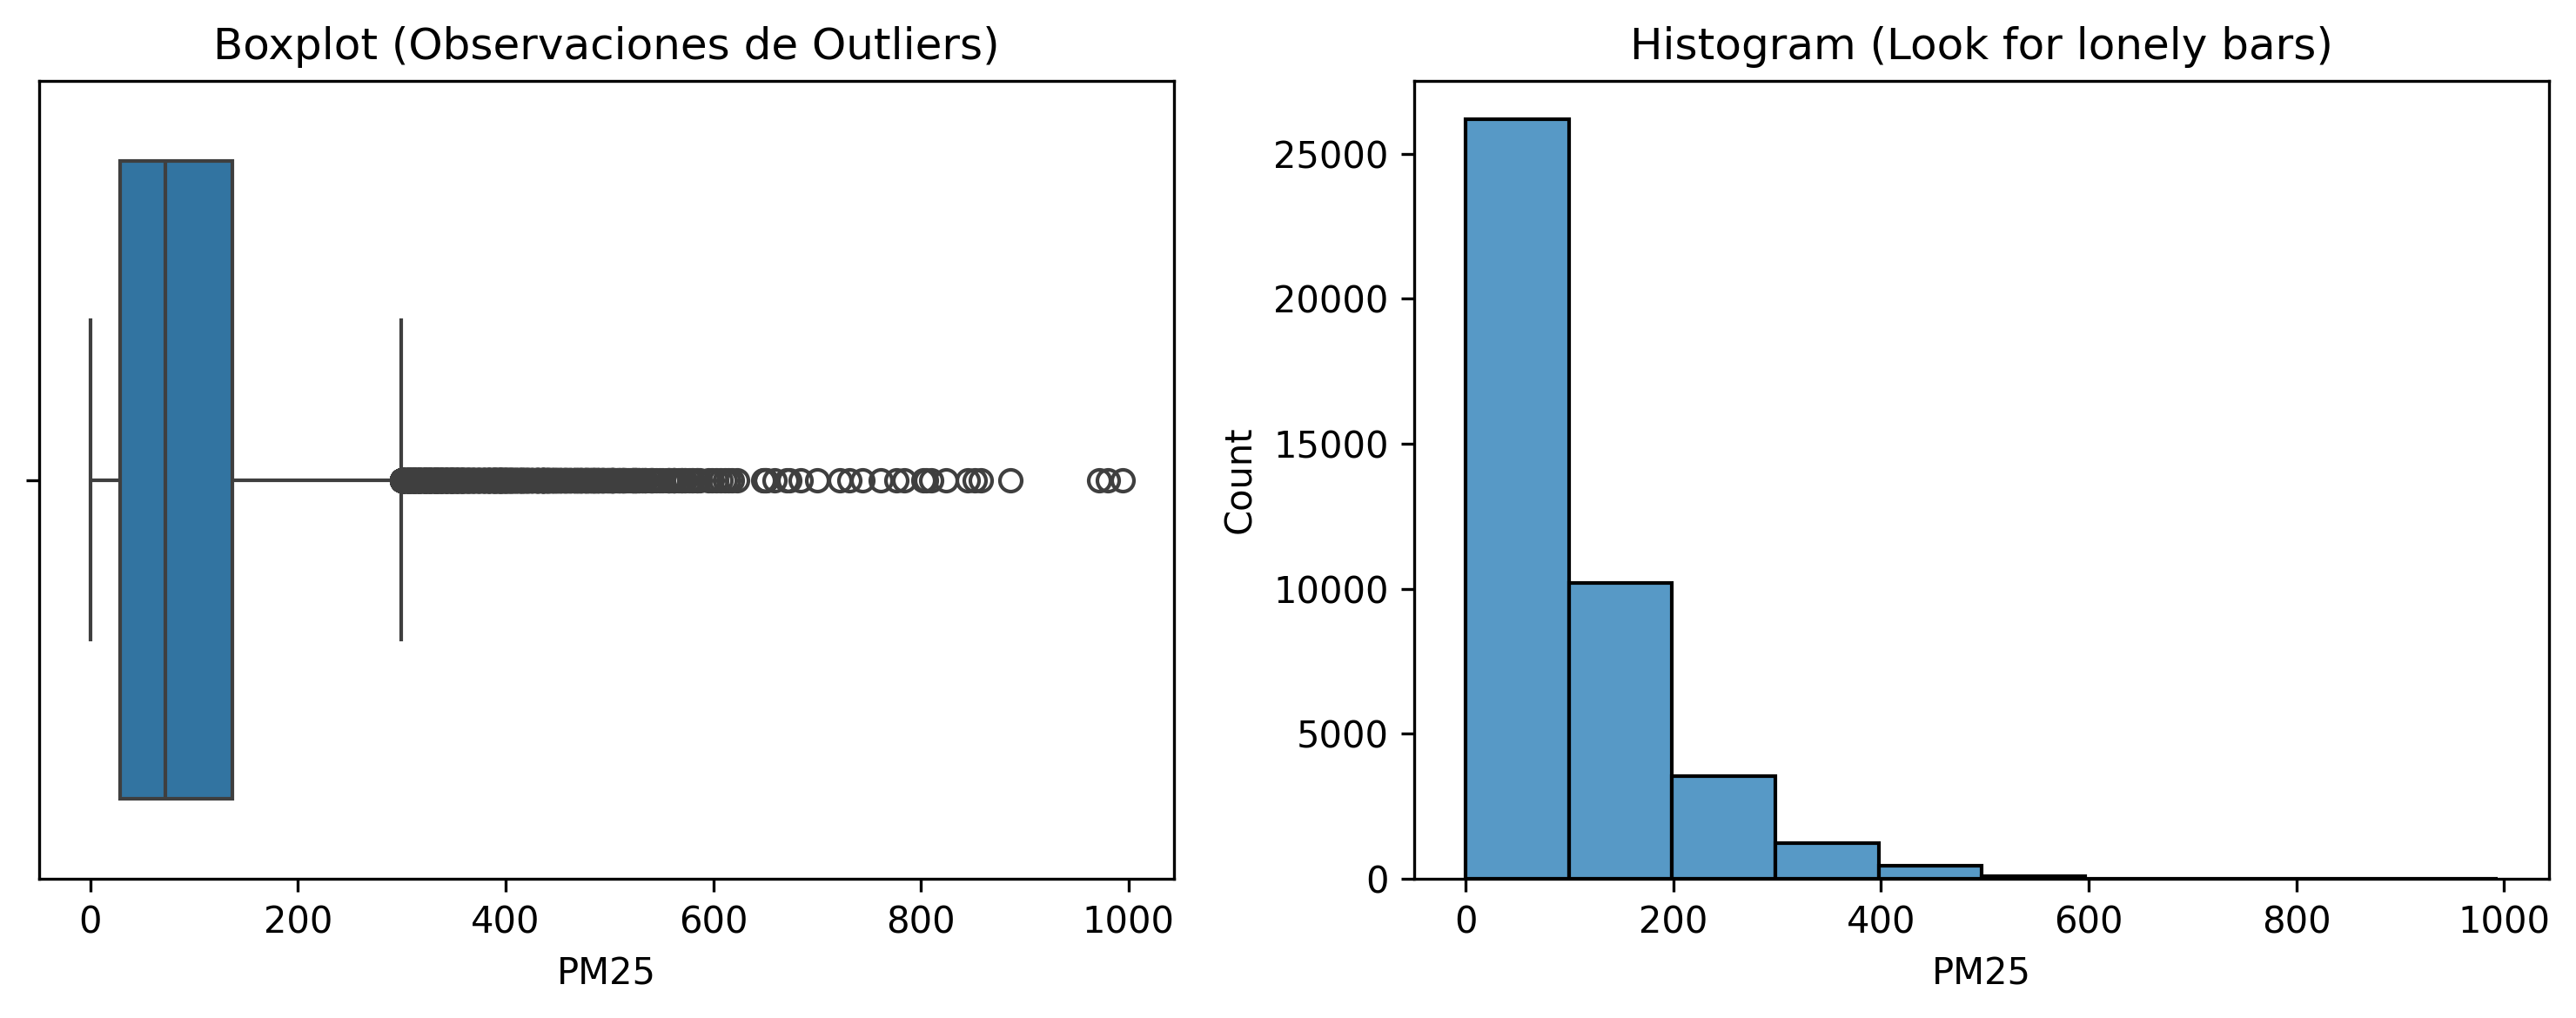

In [ ]:
# Para elegir el metodo de imputación, observamos los outliers del dataset
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.boxplot(x=df["PM25"])
plt.title("Boxplot (Observaciones de Outliers)")

plt.subplot(1, 2, 2)
sns.histplot(df["PM25"], bins=10)
plt.title("Histogram (Look for lonely bars)")

plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

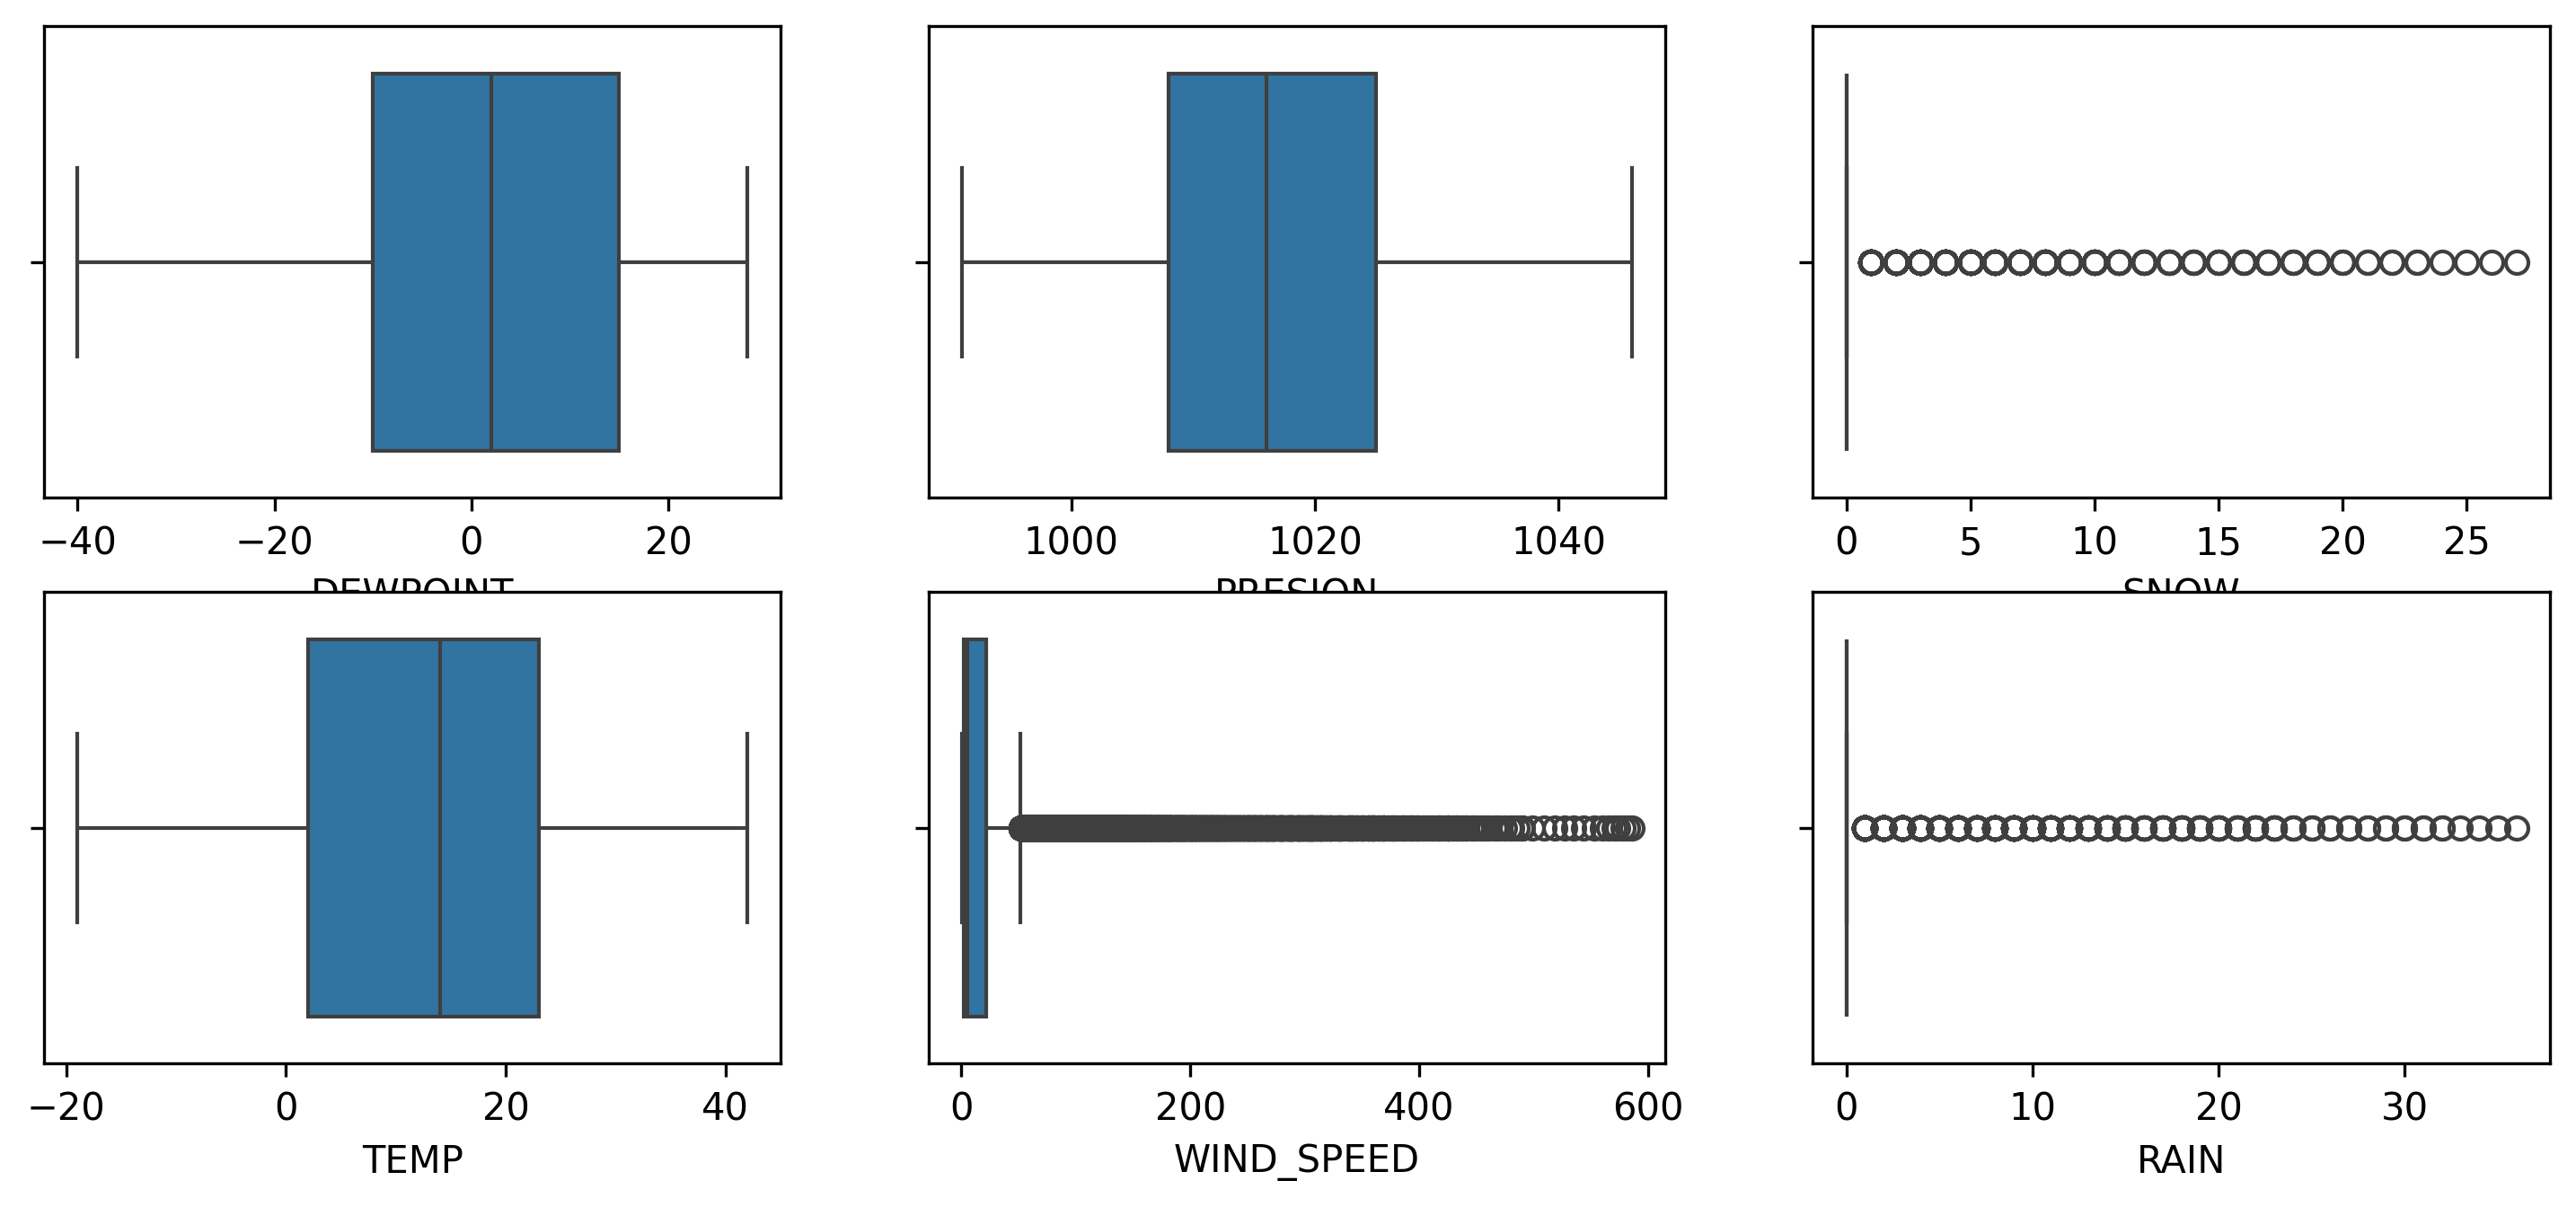

In [ ]:
# Analisis de outliers para cada variable

plt.rcParams["figure.dpi"] = 300

fig, axs = plt.subplots(2, 3, figsize=(12,5))

sns.boxplot(x="DEWPOINT", data=df, ax=axs[0,0])
sns.boxplot(x="TEMP", data=df, ax=axs[1,0])
sns.boxplot(x="PRESION", data=df, ax=axs[0,1])
sns.boxplot(x="WIND_SPEED", data=df, ax=axs[1,1])
sns.boxplot(x="SNOW", data=df, ax=axs[0,2])
sns.boxplot(x="RAIN", data=df, ax=axs[1,2])

plt.show

# SNOW y RAIN la mayoria de sus valores son 0, por eso la grafica de caja es una linea llena de outliers

In [ ]:
# Emmanuel: No me queda del todo claro que metodo de imputación elegir lol
# Entonces crearé diferetes dataset con diferentes metodos de imputación
df_imputed_mean = df_final.copy()
df_imputed_median = df_final.copy()

# imputaición con media (no aprecia tanto los outliers)
numeric_imputer_mean = SimpleImputer(strategy="mean")
df_imputed_mean["PM25_IMPUTED_MEAN"] = numeric_imputer_mean.fit_transform(df[["PM25"]])
# imputación con mediana (Maneja mejor los outliers)
numeric_imputer_median = SimpleImputer(strategy="median")
df_imputed_median["PM25_IMPUTED_MEDIAN"] = numeric_imputer_median.fit_transform(df[["PM25"]])

# Aqui nuestras columnas por modelar son:
# - PM25_IMPUTED_MEAN
# - PM25_IMPUTED_MEDIAN

print("Base de datos Imputada")
display(df_imputed_mean.sample(3))
display(df_imputed_median.sample(3))

# Habia otra forma mas rápida con Pandas, otra vez... (solo como observación, otra vez)
# Pero al parecer se recomienda usar la de scikit-learn
# df_encoded_by_pandas["PM25_IMPUTED_MEAN"] = df["PM25"].fillna(df["PM25"].mean())
# df_encoded_by_pandas["PM25_IMPUTED_MEDIAN"] = df["PM25"].fillna(df["PM25"].median())
# print("\nBase de datos Imputada (con pandas)")
# display(df_encoded_by_pandas.head(3))

Base de datos Imputada


,NO,YEAR,MONTH,DAY,HOUR,PM25,DEWPOINT,TEMP,PRESION,WIND_SPEED,SNOW,RAIN,FECHA,FECHA_SIN_H,WIND_DIRECTION_NE,WIND_DIRECTION_NW,WIND_DIRECTION_SE,WIND_DIRECTION_cv,PM25_IMPUTED_MEAN
19159,19160,2012,3,9,7,120.0,-8,-7.0,1030.0,0.89,0,0,2012-03-09 07:00:00,2012-03-09,1.0,0.0,0.0,0.0,120.0
40449,40450,2014,8,13,9,53.0,18,20.0,1009.0,4.92,0,6,2014-08-13 09:00:00,2014-08-13,0.0,0.0,1.0,0.0,53.0
32369,32370,2013,9,10,17,12.0,1,29.0,1011.0,38.01,0,0,2013-09-10 17:00:00,2013-09-10,0.0,1.0,0.0,0.0,12.0


,NO,YEAR,MONTH,DAY,HOUR,PM25,DEWPOINT,TEMP,PRESION,WIND_SPEED,SNOW,RAIN,FECHA,FECHA_SIN_H,WIND_DIRECTION_NE,WIND_DIRECTION_NW,WIND_DIRECTION_SE,WIND_DIRECTION_cv,PM25_IMPUTED_MEDIAN
4566,4567,2010,7,10,6,108.0,19,20.0,1006.0,9.84,0,0,2010-07-10 06:00:00,2010-07-10,0.0,0.0,1.0,0.0,108.0
31040,31041,2013,7,17,8,47.0,19,25.0,1006.0,0.89,0,0,2013-07-17 08:00:00,2013-07-17,0.0,0.0,0.0,1.0,47.0
34307,34308,2013,11,30,11,20.0,-17,10.0,1025.0,9.83,0,0,2013-11-30 11:00:00,2013-11-30,0.0,1.0,0.0,0.0,20.0


In [ ]:
# K-Nearest Neighbors (KNN), este tipo de imputación es bueno para datasets con variables agrupadas
# Que WIND_DIRECTION es la única variable categorica (factor)

df_numerico = df_final.select_dtypes(include=["number"])

knn_imputer = KNNImputer(n_neighbors=2)
imputed_data = knn_imputer.fit_transform(df_numerico)
df_imputed_KNN = pd.DataFrame(imputed_data, columns=df_numerico.columns)

# df_imputer_KNN es nuestro dataframe con metodo de imputación KNN
# en este la variable a modelas sigue siendo PM25

display(df_imputed_KNN.head(3))
display(df_imputed_KNN.isnull().sum())

,NO,YEAR,MONTH,DAY,HOUR,PM25,DEWPOINT,TEMP,PRESION,WIND_SPEED,SNOW,RAIN,WIND_DIRECTION_NE,WIND_DIRECTION_NW,WIND_DIRECTION_SE,WIND_DIRECTION_cv
0,1.0,2010.0,1.0,1.0,0.0,138.5,-21.0,-11.0,1021.0,1.79,0.0,0.0,0.0,1.0,0.0,0.0
1,2.0,2010.0,1.0,1.0,1.0,138.5,-21.0,-12.0,1020.0,4.92,0.0,0.0,0.0,1.0,0.0,0.0
2,3.0,2010.0,1.0,1.0,2.0,138.5,-21.0,-11.0,1019.0,6.71,0.0,0.0,0.0,1.0,0.0,0.0


,0
NO,0
YEAR,0
MONTH,0
DAY,0
HOUR,0
PM25,0
DEWPOINT,0
TEMP,0
PRESION,0
WIND_SPEED,0


In [ ]:
# Iterative Imputation (MICE), supuestamente el mejor

mice_imputer = IterativeImputer(max_iter=10, random_state=0)
mice_imputer_data = mice_imputer.fit_transform(df_numerico)
df_imputed_mice = pd.DataFrame(mice_imputer_data, columns=df_numerico.columns)

# df_imputed_mice
# vairable a modelar imputada: PM25

display(df_imputed_mice.head(3))
display(df_imputed_mice.isnull().sum())

,NO,YEAR,MONTH,DAY,HOUR,PM25,DEWPOINT,TEMP,PRESION,WIND_SPEED,SNOW,RAIN,WIND_DIRECTION_NE,WIND_DIRECTION_NW,WIND_DIRECTION_SE,WIND_DIRECTION_cv
0,1.0,2010.0,1.0,1.0,0.0,115.068227,-21.0,-11.0,1021.0,1.79,0.0,0.0,0.0,1.0,0.0,0.0
1,2.0,2010.0,1.0,1.0,1.0,123.984317,-21.0,-12.0,1020.0,4.92,0.0,0.0,0.0,1.0,0.0,0.0
2,3.0,2010.0,1.0,1.0,2.0,119.908046,-21.0,-11.0,1019.0,6.71,0.0,0.0,0.0,1.0,0.0,0.0


,0
NO,0
YEAR,0
MONTH,0
DAY,0
HOUR,0
PM25,0
DEWPOINT,0
TEMP,0
PRESION,0
WIND_SPEED,0


In [ ]:
# Para el escalado de variables, dado las propiedades de outliers de nuestro dataset
# Elegimos RobustScaler
# robust = RobustScaler()

# Preprocesamos los datos: Estadarización

# Para df_clean

cols_to_scale = ["DEWPOINT", "TEMP", "PRESION", "WIND_SPEED", "SNOW", "RAIN"]

ct = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), cols_to_scale)
    ],
    remainder='passthrough'
)

# Fit and transform the data
# Note: By default, this outputs a NumPy array or a Pandas DataFrame depending on your sklearn configuration
scaled_array = ct.fit_transform(df)
# Para df_imputed_mice




In [ ]:
# Expotar .csv
df_clean.to_csv(PRSA_data_clean, sep='\t', encoding='utf-8', index=False, header=True)
df_imputed_mice.to_csv(PRSA_data_mice, sep='\t', encoding='utf-8', index=False, header=True)

NameError: name 'PRSA_data_clean' is not defined

---
## RANDOM FOREST
---

In [ ]:
# Expotar .csv
# Livia: no me corria la caja de código anterior y segun yo con esto se arregla
# y ya podemos ver esos DFs con los nombres con el sub "_clean" y "_mice"
df_clean.to_csv("PRSA_data_clean.csv", sep='\t', encoding='utf-8', index=False, header=True)
df_imputed_mice.to_csv("PRSA_data_mice.csv", sep='\t', encoding='utf-8', index=False, header=True)

In [ ]:
df_clean.columns

Index(['NO', 'YEAR', 'MONTH', 'DAY', 'HOUR', 'PM25', 'DEWPOINT', 'TEMP',
       'PRESION', 'WIND_DIRECTION', 'WIND_SPEED', 'SNOW', 'RAIN', 'FECHA',
       'FECHA_SIN_H'],
      dtype='object')

In [ ]:
df_clean.dtypes

,0
NO,int64
YEAR,int64
MONTH,int64
DAY,int64
HOUR,int64
PM25,float64
DEWPOINT,int64
TEMP,float64
PRESION,float64
WIND_DIRECTION,object


In [ ]:
from sklearn.model_selection import train_test_split

X_clean, y_clean = df_clean[['NO', 'YEAR', 'MONTH', 'DAY', 'HOUR', 'DEWPOINT', 'TEMP',
       'PRESION', 'WIND_DIRECTION', 'WIND_SPEED', 'SNOW', 'RAIN']], df_clean['PM25']
# Livia: Eliminé las variables de Fecha del df ya que sklearn no la aguanta
# print(X_clean.head(5), y_clean.head(5))
X_clean = pd.get_dummies(X_clean, columns=['WIND_DIRECTION'])
# Livia: también generé las columnas dummies de la variable de la direccion del viento
# porque sino tampoco me corria

# Livia: entiendo que lo que predecimos es el valor del PM25 sin categorizar si es bueno, malo o regular-
# por lo que usar stratify no parece algo natural
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(X_clean, y_clean, test_size=0.25, random_state=2026)

print("Registros en X_train:",X_train_clean.shape[0])
print("Registros en y_train:",y_train_clean.shape[0])
print("Registros en X_test:",X_test_clean.shape[0])
print("Registros en y_test:",y_test_clean.shape[0])

Registros en X_train: 31317
Registros en y_train: 31317
Registros en X_test: 10440
Registros en y_test: 10440


In [ ]:
# Buscamos los mejores parámetros para nuestro modelo de entre un conjunto de valores.
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=2026),
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    verbose=1
)

grid.fit(X_clean, y_clean)

print("\nMejores hiperparámetros:", grid.best_params_)
print(f"Mejor neg_root_mean_squared_error CV: {grid.best_score_:.4f}")

Fitting 5 folds for each of 180 candidates, totalling 900 fits



KeyboardInterrupt



In [ ]:
rf_clean = RandomForestClassifier(n_estimators= , max_depth= , random_state=2026)
rf_clean.fit(X_train_clean, y_train_clean)
